# Human Activity Recognition (HAR) - Task 1: Exploratory Data Analysis (EDA)

This notebook covers EDA for the UCI-HAR dataset, including waveform visualization, static vs dynamic activity analysis, PCA visualizations, TSFEL feature extraction, and correlation analysis.

## 1. Load and Preprocess UCI-HAR Dataset

Load the raw accelerometer data from the inertial_signals folder, run CombineScript.py and MakeDataset.py, and prepare train, test, and validation sets focusing on the first 500 samples per activity.

In [90]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

# Correct way to load UCI-HAR Combined dataset
def load_har_combined_data(base_dir):
    data = []
    for split in ['Train', 'Test']:
        split_dir = os.path.join(base_dir, split)
        for activity in os.listdir(split_dir):
            activity_dir = os.path.join(split_dir, activity)
            if not os.path.isdir(activity_dir):
                continue
            for csv_file in os.listdir(activity_dir):
                if not csv_file.endswith('.csv'):
                    continue
                file_path = os.path.join(activity_dir, csv_file)
                arr = np.loadtxt(file_path, delimiter=',', skiprows=1)  # Skip header row
                # Only use first 500 samples (10 seconds at 50Hz)
                arr = arr[:500, :] if arr.shape[0] >= 500 else arr
                data.append({'acc_x': arr[:,0], 'acc_y': arr[:,1], 'acc_z': arr[:,2], 'activity': activity, 'subject': csv_file.replace('.csv','')})
    return pd.DataFrame(data)

combined_path = os.path.join('..\\human+activity+recognition+using+smartphones', 'Combined')
df = load_har_combined_data(combined_path)
print('Loaded HAR Combined dataset shape:', df.shape)
df.head()

Loaded HAR Combined dataset shape: (180, 5)


,acc_x,acc_y,acc_z,activity,subject
0,"[0.1811413, 0.1803886, 0.1845716, 0.1871044, 0...","[0.7878133, 0.78823, 0.7888803, 0.7884942, 0.7...","[0.581194, 0.5840168, 0.5806201, 0.5742789, 0....",LAYING,Subject_1
1,"[0.2492656, 0.2509721, 0.2504213, 0.2513036, 0...","[0.9431356, 0.9439628, 0.9441833, 0.9418377, 0...","[0.1830584, 0.1795588, 0.1842825, 0.1913469, 0...",LAYING,Subject_11
2,"[0.1772398, 0.175025, 0.1729768, 0.1744111, 0....","[0.5586502, 0.5553856, 0.5470136, 0.5372571, 0...","[0.7960635, 0.8049169, 0.8207692, 0.8331438, 0...",LAYING,Subject_14
3,"[0.07815351, 0.09271287, 0.09968984, 0.1078656...","[0.8699775, 0.8810138, 0.9187061, 0.9220691, 0...","[0.4717409, 0.4419717, 0.4121042, 0.4111509, 0...",LAYING,Subject_15
4,"[0.279494, 0.2770254, 0.2746455, 0.2762586, 0....","[0.4445977, 0.4443456, 0.443204, 0.4429631, 0....","[0.8536392, 0.8604129, 0.8620132, 0.8558263, 0...",LAYING,Subject_16


## 2. Plot Waveforms for Each Activity Class

Visualize one sample waveform from each activity class to observe similarities and differences.

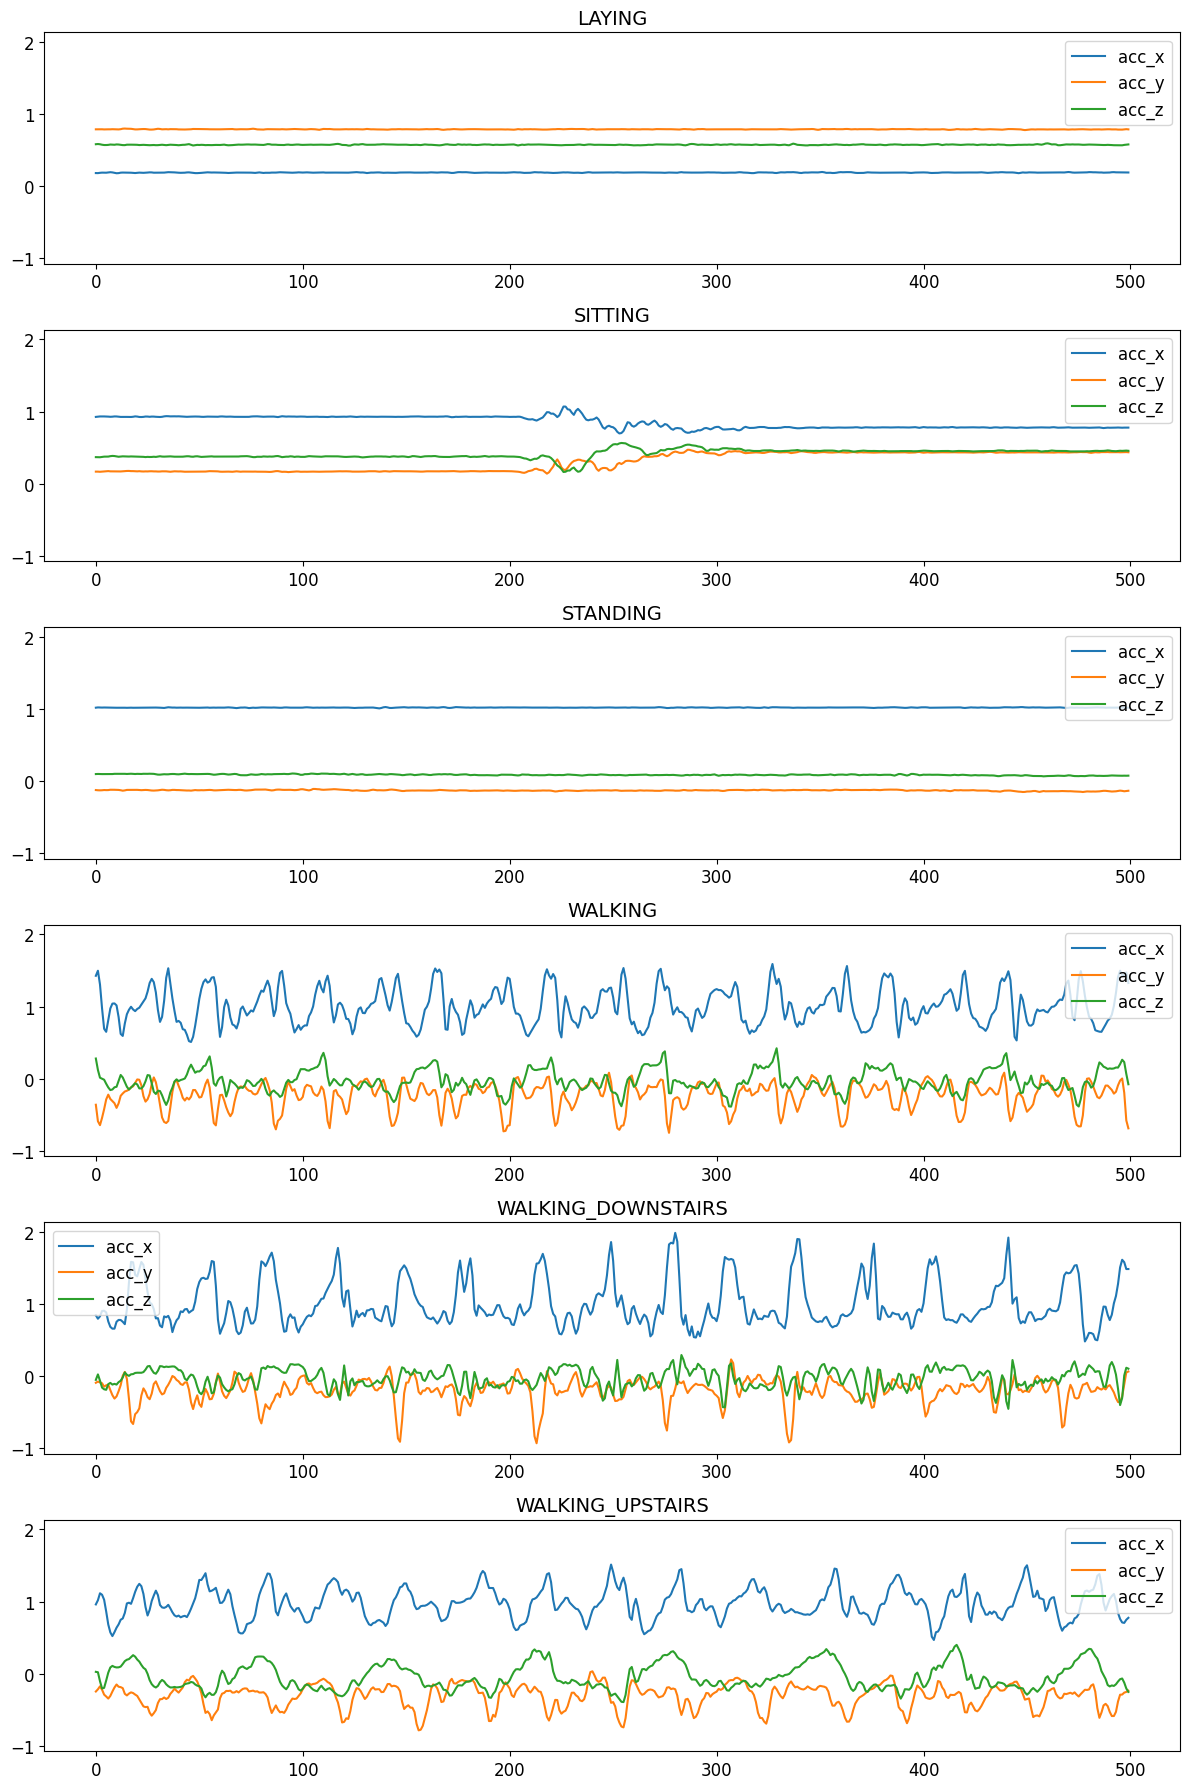

In [91]:
activity_classes = df['activity'].unique()
fig, axes = plt.subplots(len(activity_classes), 1, figsize=(12, 3 * len(activity_classes)), sharey=True)
if len(activity_classes) == 1:
    axes = [axes]
for i, activity in enumerate(activity_classes):
    sample = df[df['activity'] == activity].iloc[0]
    acc_x = sample['acc_x']
    acc_y = sample['acc_y']
    acc_z = sample['acc_z']
    axes[i].plot(acc_x, label='acc_x')
    axes[i].plot(acc_y, label='acc_y')
    axes[i].plot(acc_z, label='acc_z')
    axes[i].set_title(activity, fontsize=14)
    axes[i].legend(fontsize=12)
    axes[i].tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()

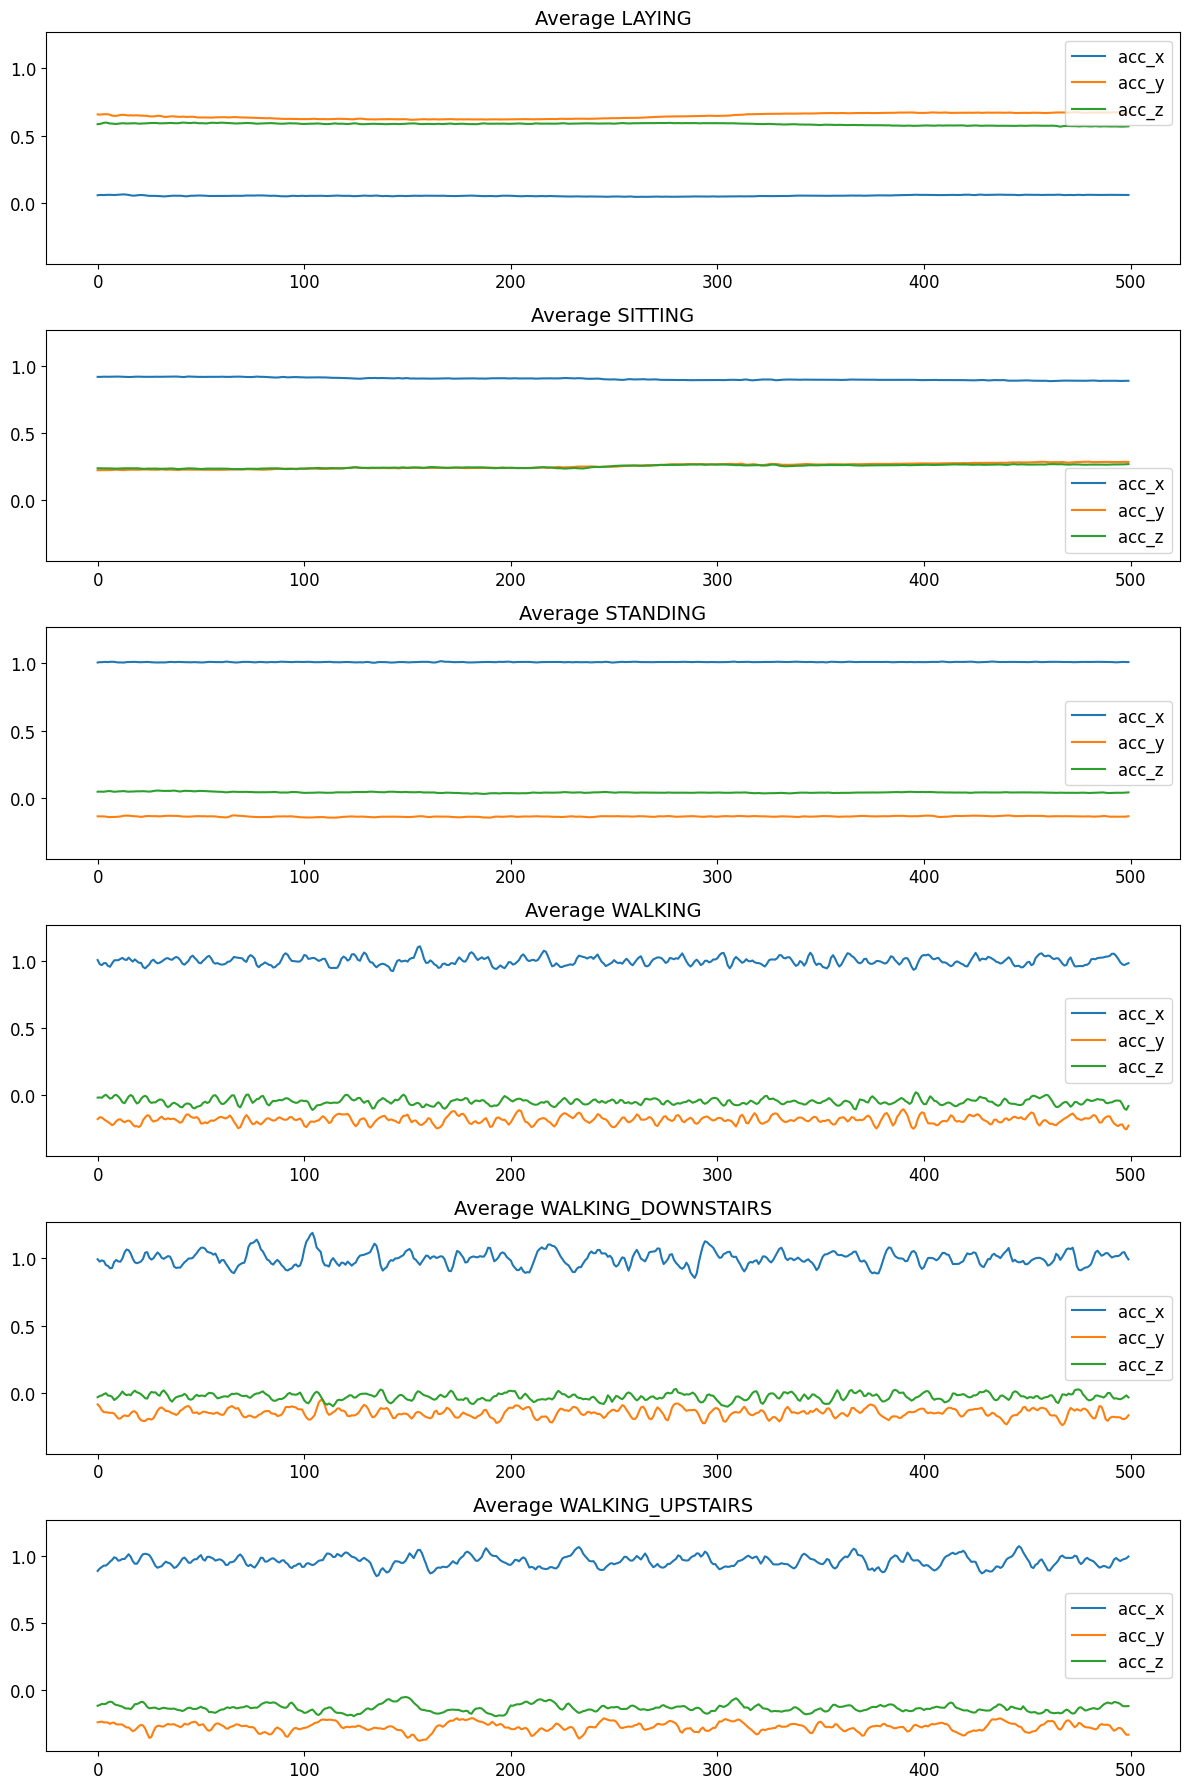

In [92]:
# plot the average signal for each activity
x_avg = df.groupby('activity')['acc_x'].apply(lambda x: np.mean(np.vstack(x), axis=0))
y_avg = df.groupby('activity')['acc_y'].apply(lambda x: np.mean(np.vstack(x), axis=0))
z_avg = df.groupby('activity')['acc_z'].apply(lambda x: np.mean(np.vstack(x), axis=0))
fig, axes = plt.subplots(len(activity_classes), 1, figsize=(12, 3 * len(activity_classes)), sharey=True)
if len(activity_classes) == 1:
    axes = [axes]
for i, activity in enumerate(activity_classes):
    acc_x = x_avg[activity]
    acc_y = y_avg[activity]
    acc_z = z_avg[activity]
    axes[i].plot(acc_x, label='acc_x')
    axes[i].plot(acc_y, label='acc_y')
    axes[i].plot(acc_z, label='acc_z')
    axes[i].set_title(f'Average {activity}', fontsize=14)
    axes[i].legend(fontsize=12)
    axes[i].tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()


## 3. Analyze Linear Acceleration for Static vs Dynamic Activities

Compute and plot linear acceleration (acc_x^2 + acc_y^2 + acc_z^2) for each activity class to compare static and dynamic activities.

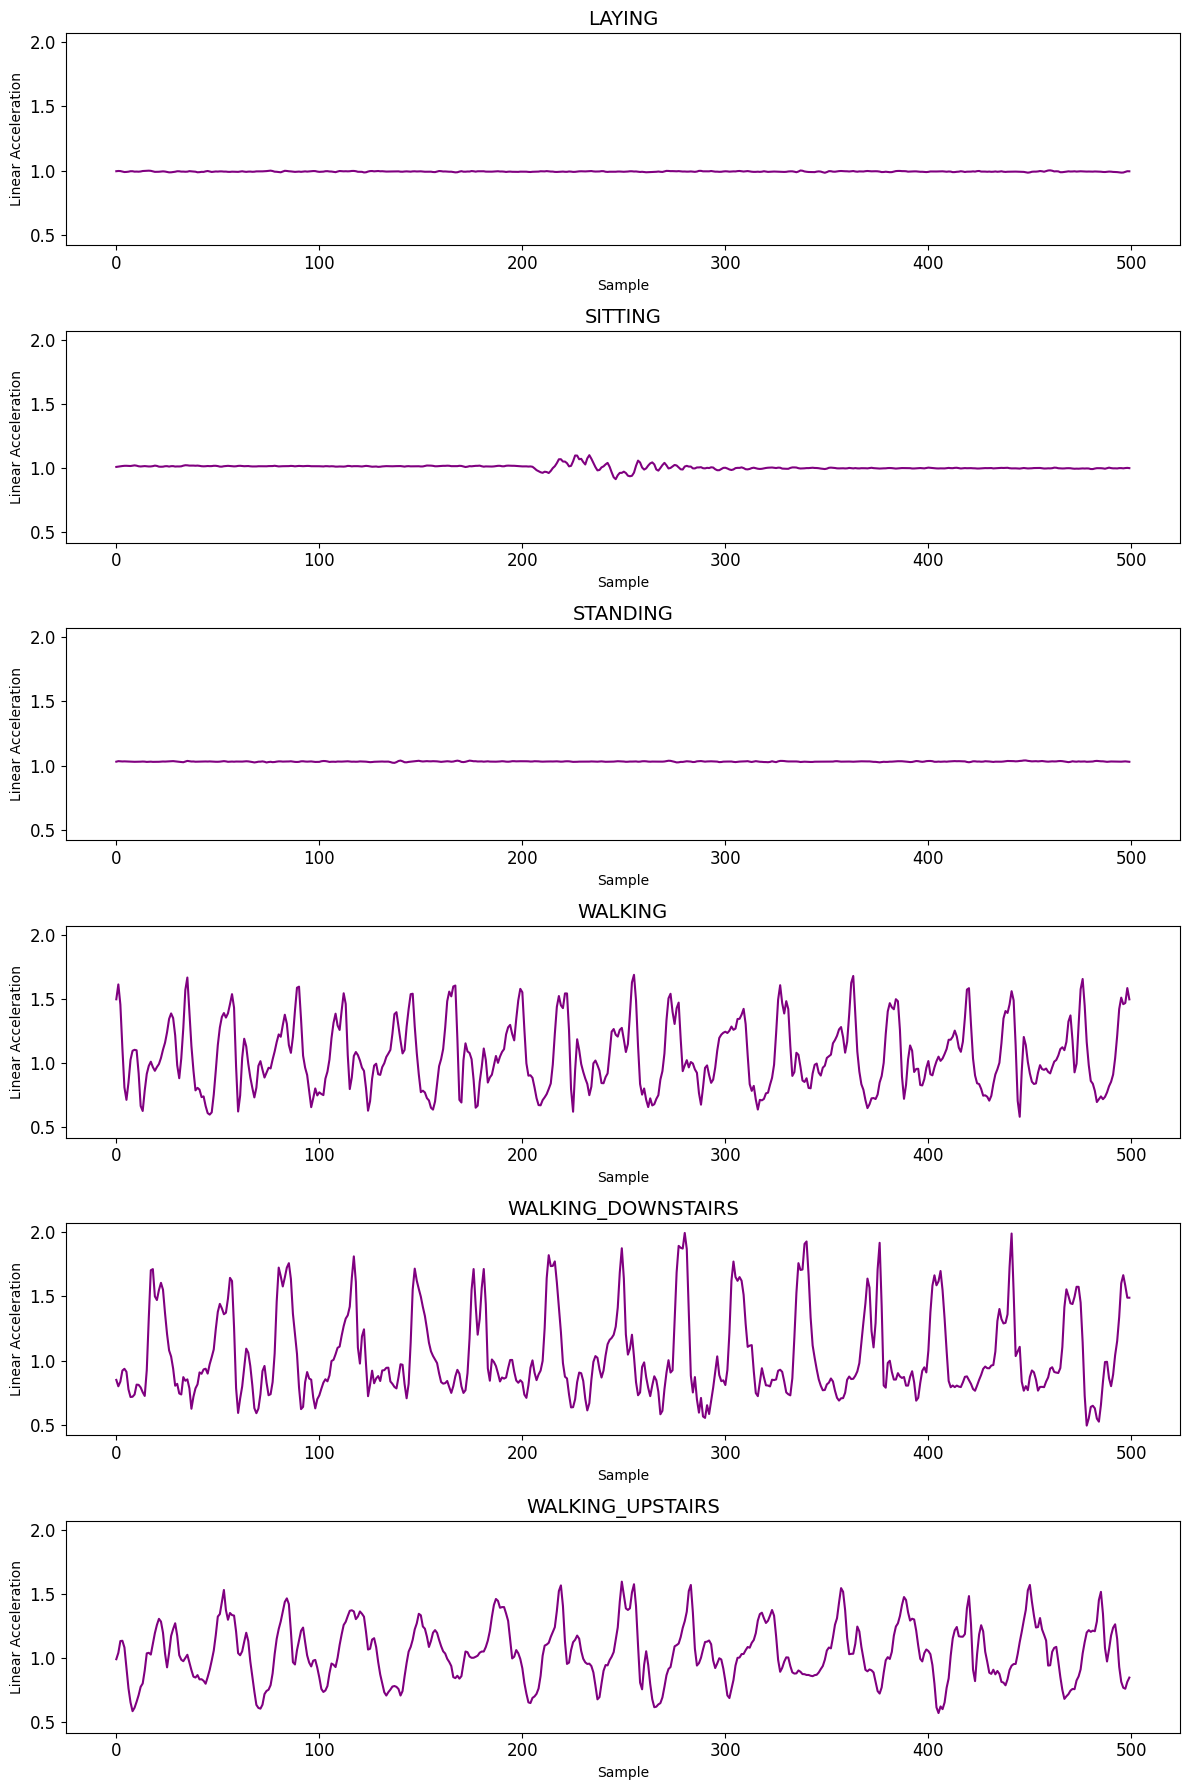

In [93]:
activity_classes = df['activity'].unique()
fig, axes = plt.subplots(len(activity_classes), 1, figsize=(12, 3 * len(activity_classes)), sharey=True)
if len(activity_classes) == 1:
    axes = [axes]
for i, activity in enumerate(activity_classes):
    sample = df[df['activity'] == activity].iloc[0]
    acc_x = sample['acc_x']
    acc_y = sample['acc_y']
    acc_z = sample['acc_z']
    linear_acc = (acc_x**2 + acc_y**2 + acc_z**2)**0.5
    axes[i].plot(linear_acc, color='purple')
    axes[i].set_title(activity, fontsize=14)
    axes[i].set_xlabel('Sample')
    axes[i].set_ylabel('Linear Acceleration')
    axes[i].tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()

## 4. PCA Visualization on Total Acceleration

Apply PCA on total acceleration to reduce to two features and plot a scatter plot for activity classes.

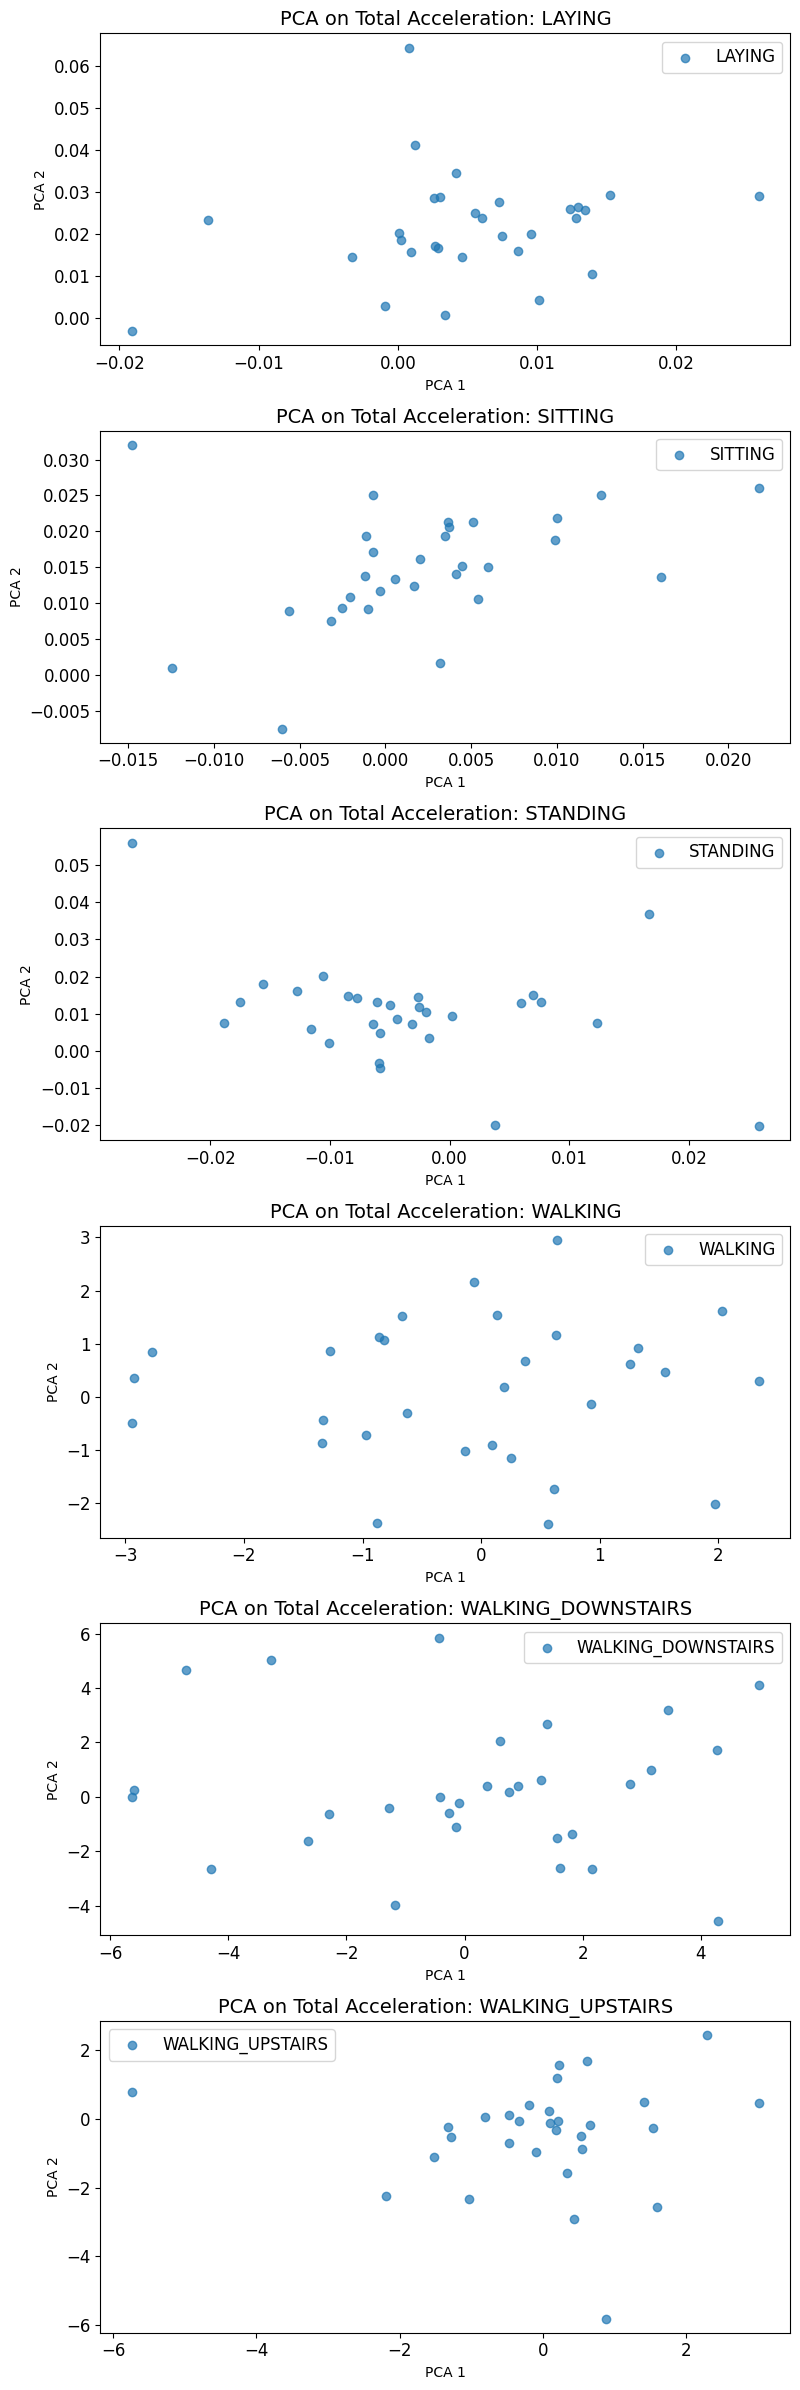

In [94]:
# Prepare total acceleration features for PCA
X_total_acc = []
y_labels = []
for idx, row in df.iterrows():
    acc_x = row['acc_x']
    acc_y = row['acc_y']
    acc_z = row['acc_z']
    total_acc = (acc_x**2 + acc_y**2 + acc_z**2)**0.5
    X_total_acc.append(total_acc)
    y_labels.append(row['activity'])
X_total_acc = np.array(X_total_acc)
df['total_acc'] = list(X_total_acc)
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_total_acc)

# Plot vertically stacked scatter plots for each activity
activity_classes = np.unique(y_labels)
fig, axes = plt.subplots(len(activity_classes), 1, figsize=(8, 4 * len(activity_classes)))
if len(activity_classes) == 1:
    axes = [axes]
for i, activity in enumerate(activity_classes):
    idxs = [j for j, a in enumerate(y_labels) if a == activity]
    axes[i].scatter(X_pca[idxs, 0], X_pca[idxs, 1], label=activity, alpha=0.7)
    axes[i].set_title(f'PCA on Total Acceleration: {activity}', fontsize=14)
    axes[i].set_xlabel('PCA 1')
    axes[i].set_ylabel('PCA 2')
    axes[i].legend(fontsize=12)
    axes[i].tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()

## 5. Feature Extraction with TSFEL and PCA Visualization

Extract features using TSFEL, apply PCA to reduce to two features, and plot a scatter plot for activity classes.

C:\Users\sun\AppData\Local\Temp\ipykernel_6052\3297726272.py:13: UserWarning: Using default sampling frequency set in configuration file.
  features = tsfel.time_series_features_extractor(cfg, acc_x, verbose=0)
C:\Users\sun\AppData\Local\Temp\ipykernel_6052\3297726272.py:13: UserWarning: Using default sampling frequency set in configuration file.
  features = tsfel.time_series_features_extractor(cfg, acc_x, verbose=0)
C:\Users\sun\AppData\Local\Temp\ipykernel_6052\3297726272.py:13: UserWarning: Using default sampling frequency set in configuration file.
  features = tsfel.time_series_features_extractor(cfg, acc_x, verbose=0)
C:\Users\sun\AppData\Local\Temp\ipykernel_6052\3297726272.py:13: UserWarning: Using default sampling frequency set in configuration file.
  features = tsfel.time_series_features_extractor(cfg, acc_x, verbose=0)
C:\Users\sun\AppData\Local\Temp\ipykernel_6052\3297726272.py:13: UserWarning: Using default sampling frequency set in configuration file.
  features = tsfel

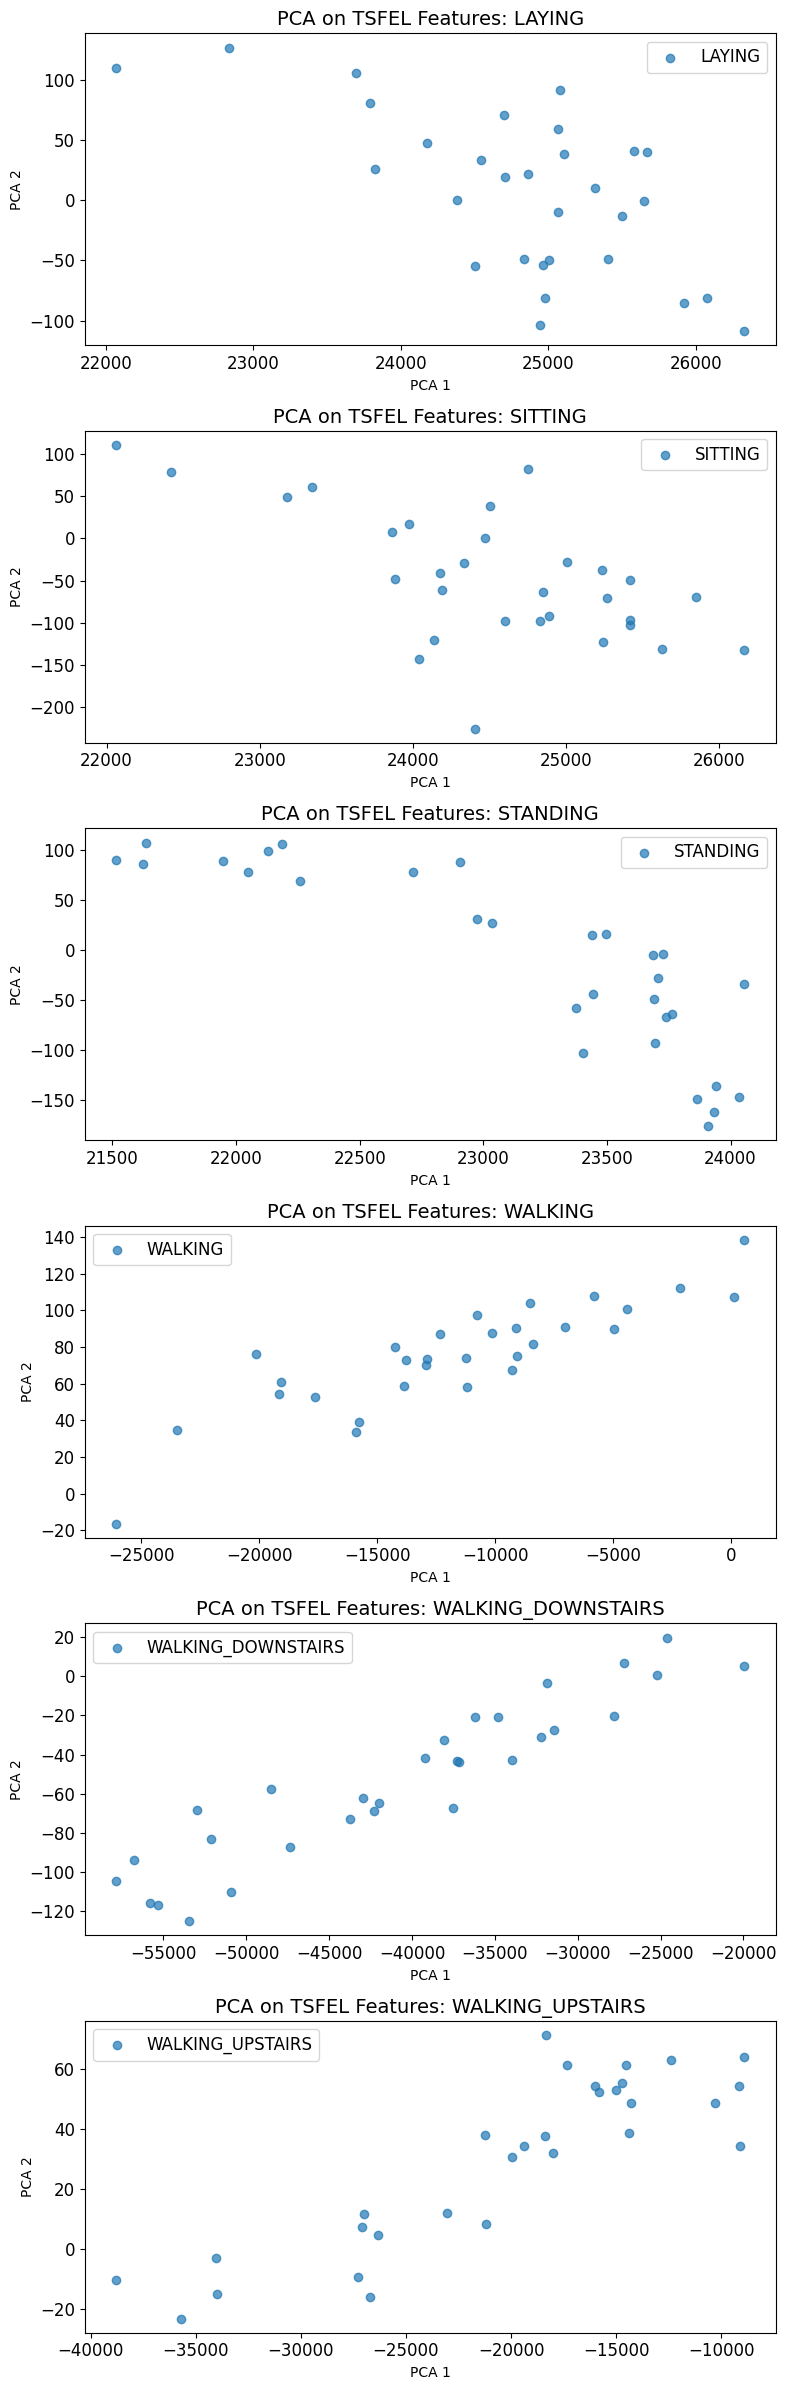

In [95]:
# Install TSFEL if not already installed
try:
    import tsfel
except ImportError:
    !pip install tsfel
    import tsfel

# Extract TSFEL features for each sample (using acc_x as example)
cfg = tsfel.get_features_by_domain()
ts_features = []
for idx, row in df.iterrows():
    acc_x = row['total_acc']
    features = tsfel.time_series_features_extractor(cfg, acc_x, verbose=0)
    ts_features.append(features.values.flatten())
ts_features = np.array(ts_features)

# Apply PCA
pca = PCA(n_components=2)
ts_pca = pca.fit_transform(ts_features)

# Plot vertically stacked scatter plots for each activity
activity_classes = np.unique(y_labels)
fig, axes = plt.subplots(len(activity_classes), 1, figsize=(8, 4 * len(activity_classes)))
if len(activity_classes) == 1:
    axes = [axes]
for i, activity in enumerate(activity_classes):
    idxs = [j for j, a in enumerate(y_labels) if a == activity]
    axes[i].scatter(ts_pca[idxs, 0], ts_pca[idxs, 1], label=activity, alpha=0.7)
    axes[i].set_title(f'PCA on TSFEL Features: {activity}', fontsize=14)
    axes[i].set_xlabel('PCA 1')
    axes[i].set_ylabel('PCA 2')
    axes[i].legend(fontsize=12)
    axes[i].tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.show()

## 7. Correlation Analysis of TSFEL and Dataset Features

Calculate and visualize the correlation matrix for TSFEL and dataset features, identify highly correlated and redundant features.

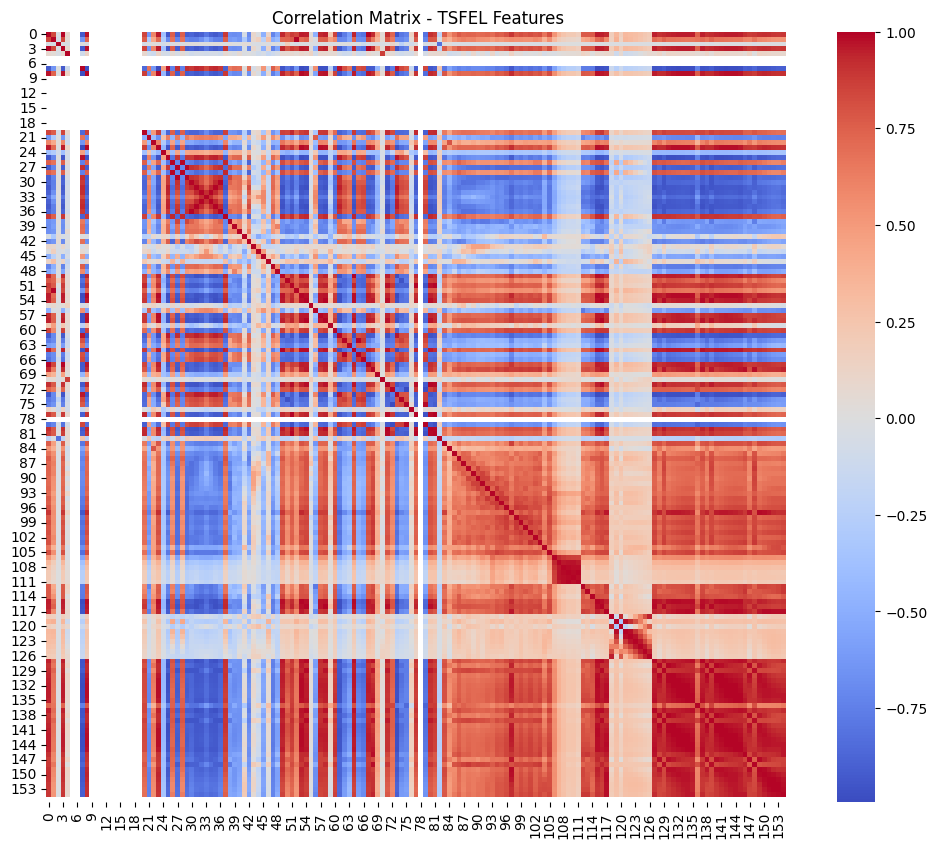

Provided dataset features are empty or invalid, cannot plot correlation matrix.
Highly correlated TSFEL feature pairs: [(np.int64(0), np.int64(0)), (np.int64(0), np.int64(3)), (np.int64(0), np.int64(7)), (np.int64(0), np.int64(8)), (np.int64(0), np.int64(23)), (np.int64(0), np.int64(25)), (np.int64(0), np.int64(27)), (np.int64(0), np.int64(29)), (np.int64(0), np.int64(31)), (np.int64(0), np.int64(35)), (np.int64(0), np.int64(49)), (np.int64(0), np.int64(53)), (np.int64(0), np.int64(54)), (np.int64(0), np.int64(57)), (np.int64(0), np.int64(58)), (np.int64(0), np.int64(61)), (np.int64(0), np.int64(64)), (np.int64(0), np.int64(67)), (np.int64(0), np.int64(68)), (np.int64(0), np.int64(71)), (np.int64(0), np.int64(73)), (np.int64(0), np.int64(80)), (np.int64(0), np.int64(115)), (np.int64(0), np.int64(116)), (np.int64(0), np.int64(117)), (np.int64(0), np.int64(127)), (np.int64(0), np.int64(128)), (np.int64(0), np.int64(129)), (np.int64(0), np.int64(130)), (np.int64(0), np.int64(131)), (np.in

In [96]:
# Correlation matrix for TSFEL features
if ts_features is not None and len(ts_features) > 0 and ts_features.shape[1] > 0:
    corr_tsfel = pd.DataFrame(ts_features).corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_tsfel, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix - TSFEL Features')
    plt.show()
else:
    print('TSFEL features are empty or invalid, cannot plot correlation matrix.')

# Correlation matrix for provided dataset features
if X_dataset_features is not None and X_dataset_features.shape[1] > 0:
    corr_dataset = pd.DataFrame(X_dataset_features).corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_dataset, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix - Provided Dataset Features')
    plt.show()
else:
    print('Provided dataset features are empty or invalid, cannot plot correlation matrix.')

# Identify highly correlated features (threshold > 0.9)
if ts_features is not None and len(ts_features) > 0 and ts_features.shape[1] > 0:
    high_corr_tsfel = np.where(np.abs(corr_tsfel) > 0.9)
    print('Highly correlated TSFEL feature pairs:', list(zip(high_corr_tsfel[0], high_corr_tsfel[1])))
if X_dataset_features is not None and X_dataset_features.shape[1] > 0:
    high_corr_dataset = np.where(np.abs(corr_dataset) > 0.9)
    print('Highly correlated dataset feature pairs:', list(zip(high_corr_dataset[0], high_corr_dataset[1])))

## 8. FFT Analysis of Acceleration Signals

Perform FFT analysis on the acceleration signals (acc_x, acc_y, acc_z) for each activity class and plot the frequency spectrum.

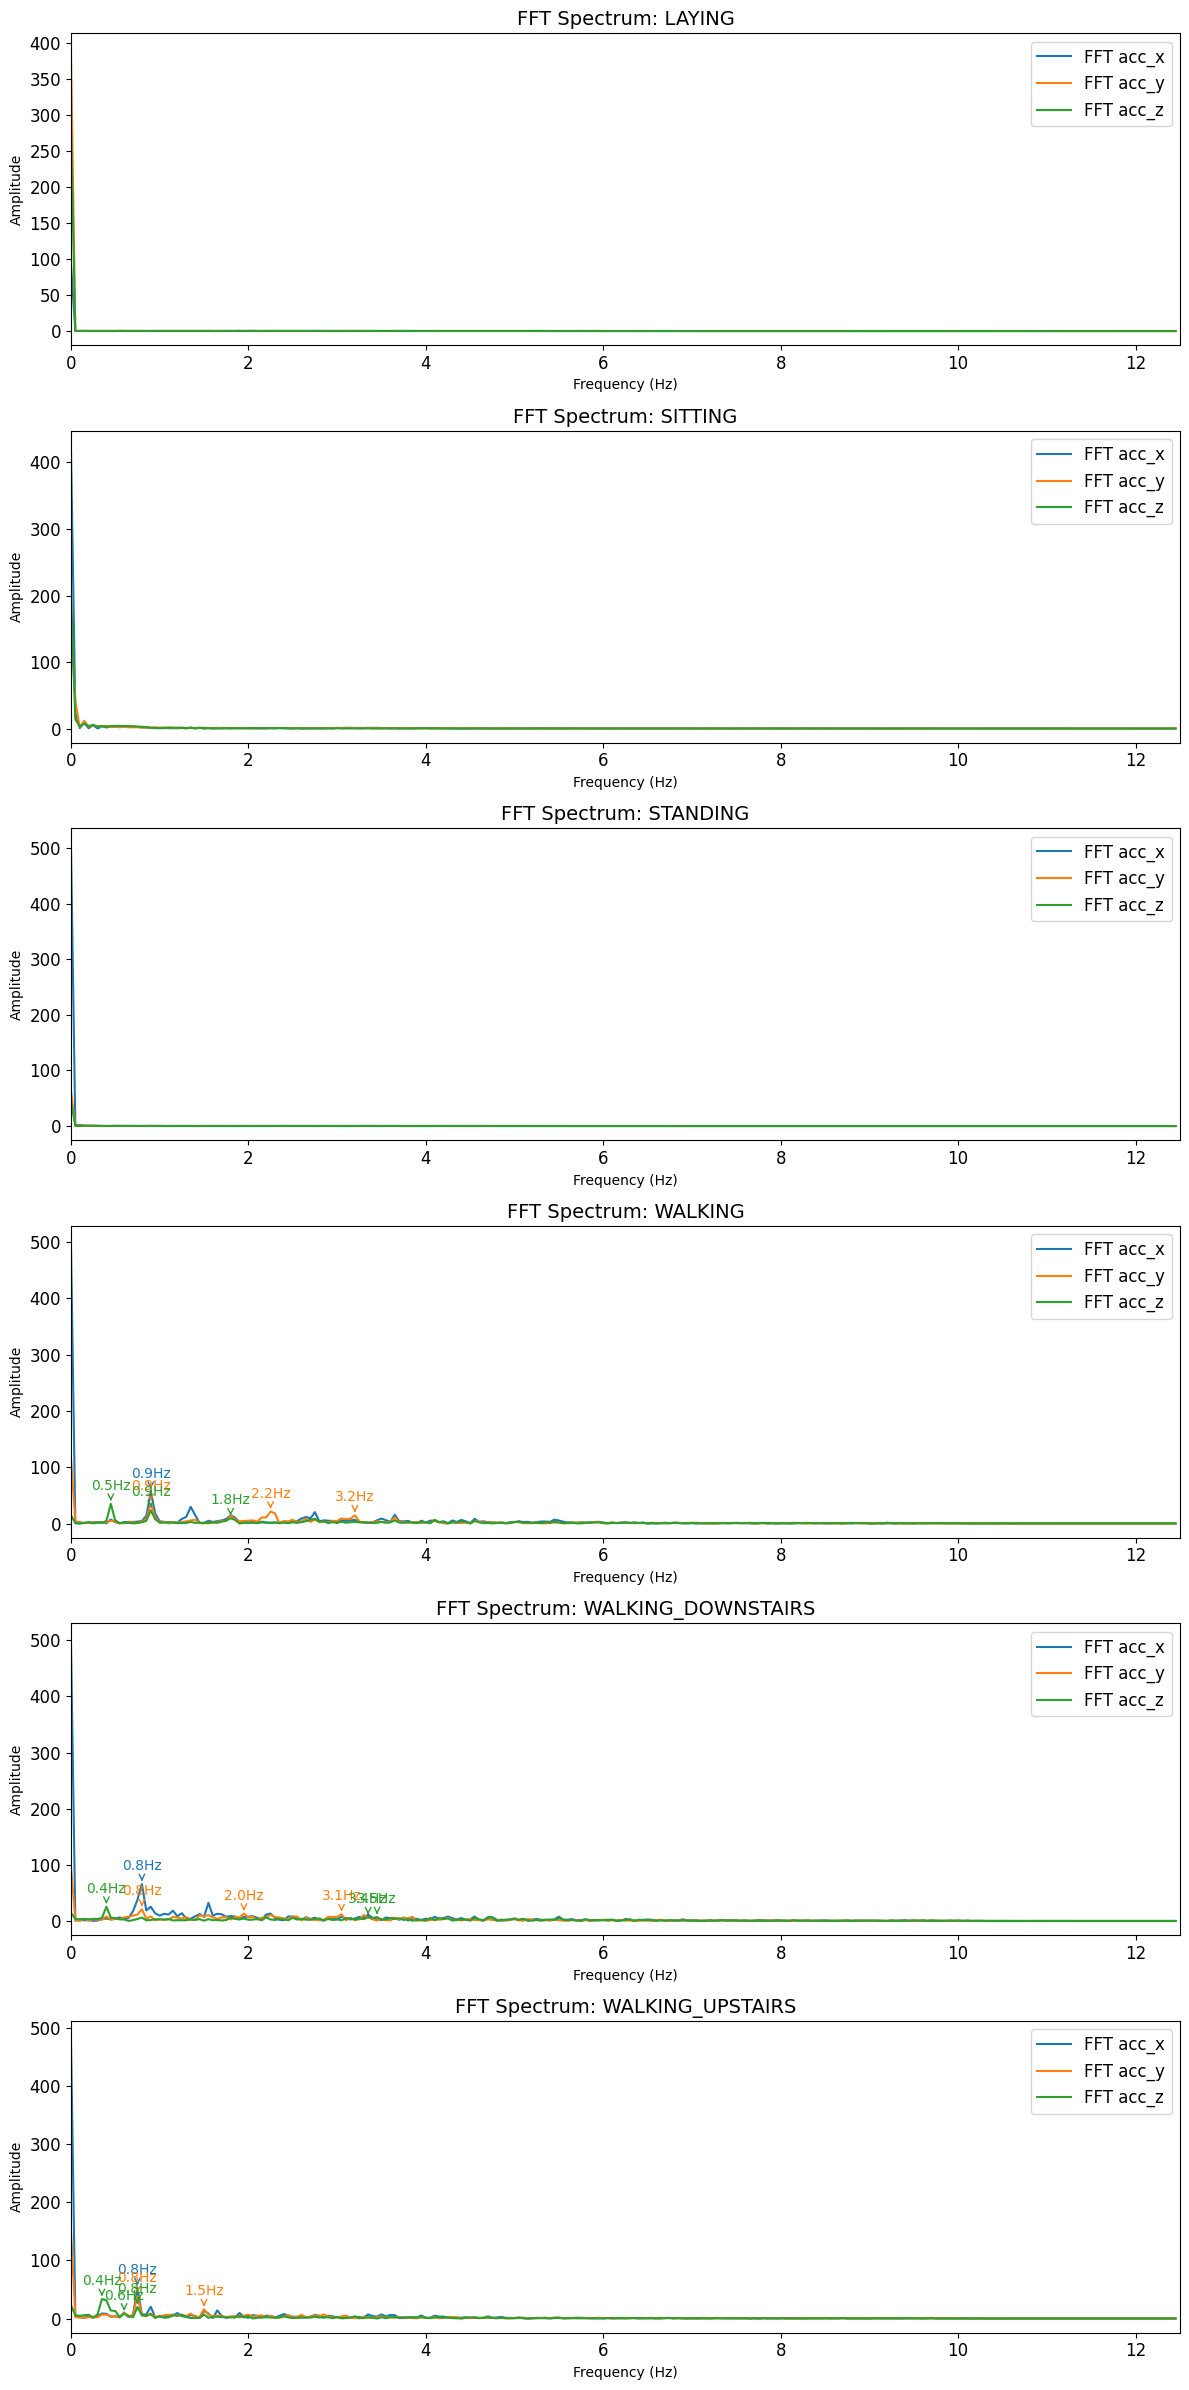

In [97]:
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

sampling_rate = 25  # Hz
n_samples = 500
num_peaks = 3  # Number of peaks to label

activity_classes = df['activity'].unique()
fig, axes = plt.subplots(len(activity_classes), 1, figsize=(12, 4 * len(activity_classes)), sharey=False)
if len(activity_classes) == 1:
    axes = [axes]
for i, activity in enumerate(activity_classes):
    sample = df[df['activity'] == activity].iloc[0]
    acc_x = sample['acc_x']
    acc_y = sample['acc_y']
    acc_z = sample['acc_z']

    # FFT for each axis
    f = fftfreq(n_samples, 1/sampling_rate)[:n_samples//2]
    fft_x = np.abs(fft(acc_x))[:n_samples//2]
    fft_y = np.abs(fft(acc_y))[:n_samples//2]
    fft_z = np.abs(fft(acc_z))[:n_samples//2]

    axes[i].plot(f, fft_x, label='FFT acc_x')
    axes[i].plot(f, fft_y, label='FFT acc_y')
    axes[i].plot(f, fft_z, label='FFT acc_z')

    # Find and label peaks for each axis
    for fft_data, axis_label, color in zip([fft_x, fft_y, fft_z], ['acc_x', 'acc_y', 'acc_z'], ['C0', 'C1', 'C2']):
        peaks, _ = find_peaks(fft_data, height=np.max(fft_data)*0.1)
        # Sort peaks by amplitude and select top N
        top_peaks = peaks[np.argsort(fft_data[peaks])[-num_peaks:]] if len(peaks) >= num_peaks else peaks
        for peak in top_peaks:
            axes[i].annotate(f'{f[peak]:.1f}Hz',
                           (f[peak], fft_data[peak]),
                           textcoords="offset points",
                           xytext=(0,10),
                           ha='center',
                           color=color,
                           fontsize=10,
                           arrowprops=dict(arrowstyle='->', color=color))

    axes[i].set_title(f'FFT Spectrum: {activity}', fontsize=14)
    axes[i].set_xlabel('Frequency (Hz)')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend(fontsize=12)
    axes[i].tick_params(axis='both', labelsize=12)
    axes[i].set_xlim(0, sampling_rate/2)
plt.tight_layout()
plt.show()